# Watermark Training and Evaluation Demo

## Config

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Alternative src path depending on the jupyter root path
sys.path.append(str(Path().resolve().parent))

In [2]:
from src.data import Dataset, Augment
from src.models import WatermarkScoreModel, Watermark, ModelWrapper, DiffusionModel, get_vae, decode
from src.training import Trainer, AugSampler
from src.evaluation import Evaluation, visualize, generate, scores
from src.utils.utils import cleanup_cuda_memory
from src.utils import Config

config = Config('config.yaml')
device = config.get_device()
print(f"Using device: {device}")

get_vae(config)
cleanup_cuda_memory(True)

Loaded config from: /home/c01huja/CISPA-home/serum-watermark-sd3/final_serum/configs/config.yaml
Using device: cuda
Loading VAE...


Couldn't connect to the Hub: 401 Client Error. (Request ID: Root=1-699a44ee-3acb82c34e23a731619ed4ba;83eff1da-64aa-46a3-a4e3-4407a6f010fb)

Repository Not Found for url: https://huggingface.co/api/models/stabilityai/stable-diffusion-2-1-base.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password..
Will try to load from local cache.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

VAE scaling factor: 0.18215
CUDA Memory - Allocated: 0.16GB, Cached: 0.17GB, Free: 38.81GB, Total: 39.39GB


## Initialize models

In [3]:
augment = Augment()
dataset = Dataset(config)

diffusion_model = ModelWrapper(DiffusionModel(config).to(device)).to(device)
watermark = Watermark(config).to(device)

score_model = WatermarkScoreModel(config).to(device)

print("Watermark Score Model:")
print(f"Total parameters: {sum(p.numel() for p in score_model.parameters()):,}")

Loading dataset: Gustavosta/Stable-Diffusion-Prompts


README.md:   0%|          | 0.00/777 [00:00<?, ?B/s]

data/train.parquet:   0%|          | 0.00/9.23M [00:00<?, ?B/s]

data/eval.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/73718 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8192 [00:00<?, ? examples/s]

Loaded 400 training prompts and 73318 test prompts


Couldn't connect to the Hub: 401 Client Error. (Request ID: Root=1-699a44f7-710b65ce540a8c022e0ebc72;6967c4d2-ada5-4e5e-9d96-2d56214a54ce)

Repository Not Found for url: https://huggingface.co/api/models/stabilityai/stable-diffusion-2-1-base.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password..
Will try to load from local cache.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loaded Stable Diffusion model: stabilityai/stable-diffusion-2-1-base
Watermark Score Model:
Total parameters: 2,487,841


## Create Data

In [6]:
# Needs to be done only once for each model version
generated_data = dataset.generate_data(
    diffusion_model=diffusion_model,
    use_test_prompts=False
)

# Alternatively, augment existing data:
#generated_data = Dataset.load_dataset(config, config.dataset.paths.generated_data_file)

augmented_data = dataset.generate_augmented_data(
    data=generated_data, 
    augmentation_pipeline=augment
)

dataset.save_dataset()
print("Data saved!")

Generating images for prompts 0 to 400
Using train prompts


Generating images:   0%|          | 0/13 [00:00<?, ?it/s]The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['incev , in style of lee souder , in plastic , dark atmosphere , tilt shift , depth of field , <|endoftext|>!!!!!!!!!!', 'trending on art station <|endoftext|>!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '<|endoftext|>!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', 'm , very coherent , triadic color scheme , art by takato yamamoto and james jean <|endoftext|>!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!

  0%|          | 0/50 [00:00<?, ?it/s]

Generating images:   8%|▊         | 1/13 [01:23<16:36, 83.07s/it]The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', ', maxfield parrish and alphonse mucha , sunrise , new art nouveau , soft ambient lighting , particle effects <|endoftext|>!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', ', octane render , trending on artstation , masterpiece <|endoftext|>!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

Generating images: 100%|██████████| 13/13 [06:01<00:00, 27.83s/it]


Last batch size 16 is smaller than 32, removing it
Generated 12 batches
Applying data augmentations...


Augmenting batches: 100%|██████████| 12/12 [01:15<00:00,  6.28s/it]


Saved generated dataset to ./datasets/data_sd21_gen_2026-02-22_01-16-51.pt with length 12
Saved augmented dataset to ./datasets/data_sd21_aug_2026-02-22_01-16-52.pt with length 12
Data saved!


## Load Data

In [11]:
train_data_gen, train_data_aug = Dataset.load_data_pair(config)
train_prompts = Dataset.get_prompts(config, use_test=False)
test_prompts = Dataset.get_prompts(config, use_test=True)
print(f"Sample prompt: {train_prompts[17]}")

Loaded dataset from ./datasets/data_sd21_gen_2026-02-22_01-16-51.pt with length 12
Loaded dataset from ./datasets/data_sd21_aug_2026-02-22_01-16-52.pt with length 12
Loading dataset: Gustavosta/Stable-Diffusion-Prompts
Loaded 400 training prompts and 73318 test prompts
Loading dataset: Gustavosta/Stable-Diffusion-Prompts
Loaded 400 training prompts and 73318 test prompts
Sample prompt: a very beautiful anime cute girl, full body, long wavy blond hair, sky blue eyes, full round face, short smile, fancy top, miniskirt, front view, medium shot, mid-shot, laying in bed,  highly detailed, cinematic wallpaper by Stanley Artgerm Lau


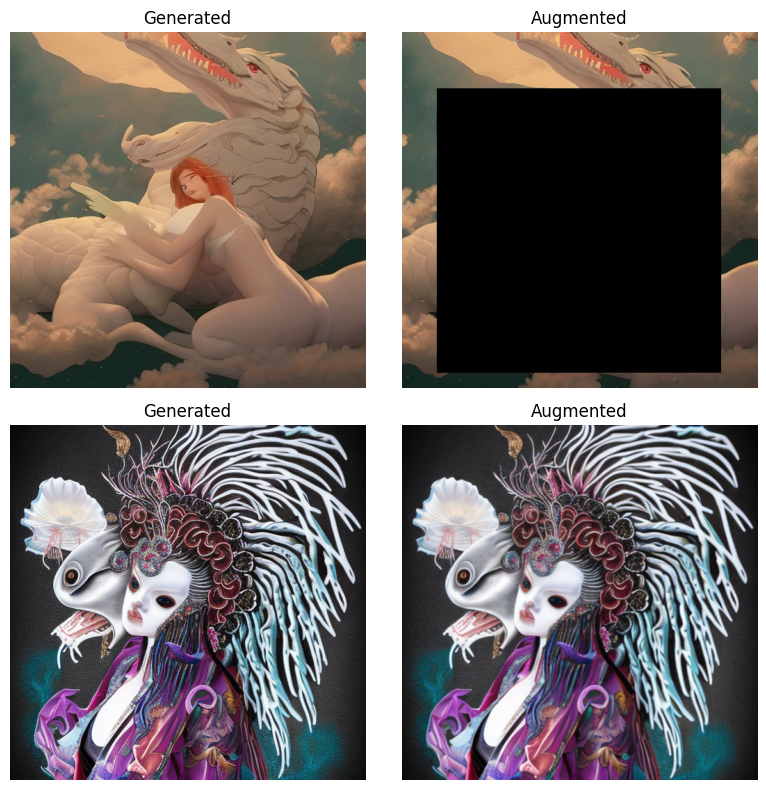

In [12]:
# Visualize the data
Dataset.visualize(train_data_gen, train_data_aug, 2)

## Train the Watermark Detector

In [13]:
# Initialize trainer
aug_sampler = AugSampler(len(augment))
trainer = Trainer(
    config=config,
    diffusion_model=diffusion_model,
    score_model=score_model,
    watermark=watermark,
    aug_sampler=aug_sampler,
    data=train_data_gen,
    data_aug=train_data_aug,
    prompts=train_prompts,
    augment=augment
)

print("Trainer initialized!")

AUG TEMP IS:  1.0
Trainer initialized!


In [14]:
# Watermark training
print("\n=== WATERMARK TRAINING ===")
train_losses = trainer.train(epochs=1, verbose=True)
print(f"Training complete. Final loss: {train_losses[-1][0]:.6f}")


=== WATERMARK TRAINING ===
Train samples: 384
No checkpoint found
Generating watermarked images for training...


  0%|          | 0/4 [00:00<?, ?it/s]The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', 'greg rutkowski and artgerm <|endoftext|>!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', 'm , very coherent , triadic color scheme , art by takato yamamoto and james jean <|endoftext|>!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '<|endoftext|>!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '<|endoftext|>!!!!!!!

  0%|          | 0/50 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [00:25<01:17, 25.99s/it]The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!', 'kowski <|endoftext|>!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!', 'huge scene , ultra - detailed trees , f 1 1 aperture , focus on trees , in the style of jim richardson', '!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!', 'greg rutkowski and artgerm <|endoftext|>!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!', '<|endoftext|>!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!', 'hag <|endo

  0%|          | 0/50 [00:00<?, ?it/s]

...

Saving watermarked dataset to results/SERUM_demo/checkpoints/watermarked_dataset_128_0.5.pt
Generated 128 watermarked images for training buffer
Checkpoint saved: results/SERUM_demo/checkpoints/checkpoint_epoch_0.pt

[Train Epoch 1/1]


  8%|▊         | 1/12 [00:29<05:20, 29.09s/it]

Batch 1
Loss: 4.224803448
Watermarked (augmented) Acc: 0.250000000
Non-Watermarked (augmented) Acc: 1.000000000
Final probabilities: [0.06852103 0.06852103 0.06852103 0.06852103 0.06852103 0.06852103
 0.06852103 0.52035278]


100%|██████████| 12/12 [00:32<00:00,  2.73s/it]


Epoch loss: 7.302620371182759
Epoch watermark accs: 0.6875
Epoch non-watermark accs: 0.375
Final probabilities: [0.05950556 0.05950556 0.05950556 0.05950556 0.05950556 0.05950556
 0.05950556 0.58346106]
Checkpoint saved: results/SERUM_demo/checkpoints/checkpoint_epoch_1.pt
Training complete. Final loss: 4.224803


In [15]:
# Save the models
score_model.save()
watermark.save()

Watermark Score Model saved to: results/SERUM_demo/models/score_model_2026-02-22_01-23-05.pt
Watermark saved to: results/SERUM_demo/models/watermark_2026-02-22_01-23-05.pt


'results/SERUM_demo/models/watermark_2026-02-22_01-23-05.pt'

In [16]:
cleanup_cuda_memory(True)

CUDA Memory - Allocated: 2.65GB, Cached: 2.78GB, Free: 36.09GB, Total: 39.39GB


## Load models

In [17]:
score_model = WatermarkScoreModel.load(config).requires_grad_(False).eval().to(device)
watermark = Watermark.load(config).requires_grad_(False).eval().to(device)

Watermark Score Model loaded from: results/SERUM_demo/models/score_model_2026-02-22_01-23-05.pt
Watermark loaded from: results/SERUM_demo/models/watermark_2026-02-22_01-23-05.pt


In [18]:
# Alternatively with a checkpoint:
score_model, watermark = Trainer.load_models_from_checkpoint(config, "./results/SERUM_demo/checkpoints/checkpoint_epoch_1.pt")
score_model = score_model.requires_grad_(False).eval().to(device)
watermark = watermark.requires_grad_(False).eval().to(device)

Loading models from checkpoint: ./results/SERUM_demo/checkpoints/checkpoint_epoch_1.pt


In [19]:
cleanup_cuda_memory(True)

CUDA Memory - Allocated: 2.66GB, Cached: 2.78GB, Free: 36.09GB, Total: 39.39GB


## Evaluation

In [20]:
# Initialize evaluator
evaluator = Evaluation(
    config=config,
    diffusion_model=diffusion_model,
    score_model=score_model,
    watermark=watermark,
    prompts=test_prompts,
    augment=augment
)

Saved 73318 positive prompts to results/SERUM_demo/gen_images/positive_prompts.txt
Saved 73318 negative prompts to results/SERUM_demo/gen_images/negative_prompts.txt



=== QUICK EVALUATION ===
Running quick evaluation...


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['carved marble texture silk cloth , latex skin , highly ornate intricate details , in the style of 8 8 grzes', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', ', masterpiece , trending on artstation , 8 k <|endoftext|>!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!']


  0%|          | 0/50 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['carved marble texture silk cloth , latex skin , highly ornate intricate details , in the style of 8 8 grzes', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', ', masterpiece , trending on artstation , 8 k <|endoftext|>!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!']


  0%|          | 0/50 [00:00<?, ?it/s]

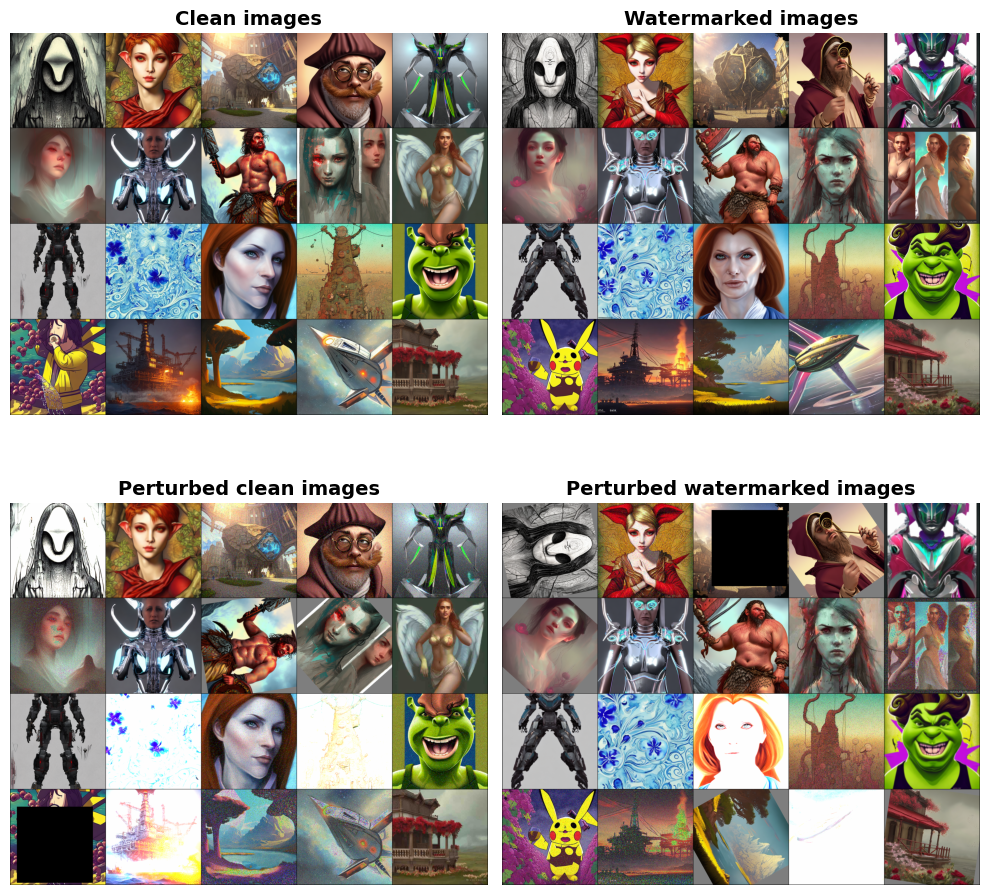

Watermark score of clean images (non-watermarked): [0.0028895216528326273, 0.43711739778518677, 0.08934249728918076, 0.23775583505630493, 0.044353194534778595, 0.522332489490509, 0.03832581639289856, 0.12450152635574341, 0.06234730780124664, 0.4906562268733978, 0.07153424620628357, 0.08413755148649216, 0.15354937314987183, 0.35354340076446533, 0.01647311821579933, 0.273785799741745, 0.07669224590063095, 0.13869555294513702, 0.19438786804676056, 0.24745605885982513]
  mean: 0.18299387395381927
  median: 0.12450152635574341
Watermark score of clean images (non-watermarked + augmented): [0.18170666694641113, 0.5092137455940247, 0.06489380449056625, 0.13883468508720398, 0.013929415494203568, 0.1739538311958313, 0.036947790533304214, 0.1507028341293335, 0.05291822552680969, 0.454945832490921, 0.08795113116502762, 0.5324938893318176, 0.05856872349977493, 0.5388461351394653, 0.015605035237967968, 0.01156024169176817, 0.5405117869377136, 0.02801898494362831, 0.04693746939301491, 0.303455799818

In [21]:
# Quick evaluation
print("\n=== QUICK EVALUATION ===")
quick_results = evaluator.quick_eval(show_images=True)

In [22]:
# Thorough evaluation with ROC
print("\n=== EVALUATION ===")
non_aug_results = evaluator.eval_tpr(
    num_samples=50
)


=== EVALUATION ===
Running evaluation with 50 samples...
Generating samples (fresh set)...


Generating batches:   0%|          | 0/2 [00:00<?, ?it/s]The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', 'k <|endoftext|>!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!

  0%|          | 0/50 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', 'k <|endoftext|>!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!', 'brushstrokes , thick paint visible , no light reflecting off paint , vibrant colors , studio lighting', '!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!']


  0%|          | 0/50 [00:00<?, ?it/s]

Generating batches: 100%|██████████| 2/2 [01:33<00:00, 46.65s/it]


Generated 50 clean and watermarked images.
Scoring clean (non-watermarked) images...
Scoring watermarked images...

Evaluation Summary
Clean: 16.0000% TPR @ 0.0000% FPR (ROC AUC: 0.7800) Thr: 0.6152 BalAcc: 0.7600
Aug: 4.0000% TPR @ 0.0000% FPR (ROC AUC: 0.6672) Thr: 0.6345 BalAcc: 0.6400
Combined: 11.0000% TPR @ 1.0000% FPR (ROC AUC: 0.7142) Thr: 0.6152 BalAcc: 0.6950

Samples: clean=50 aug_clean=50 wm=50 wm_aug=50

Saving evaluation plots...
Plots saved to results/SERUM_demo/evaluation with prefix eval_tpr


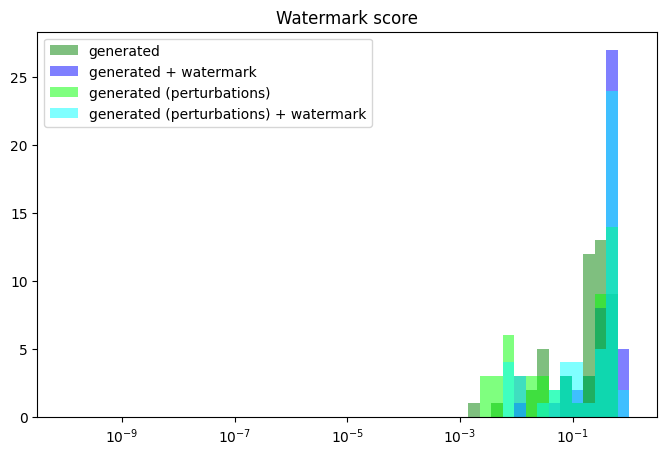

All clean samples (aug + non-aug) vs all watermarked samples (aug + non-aug)


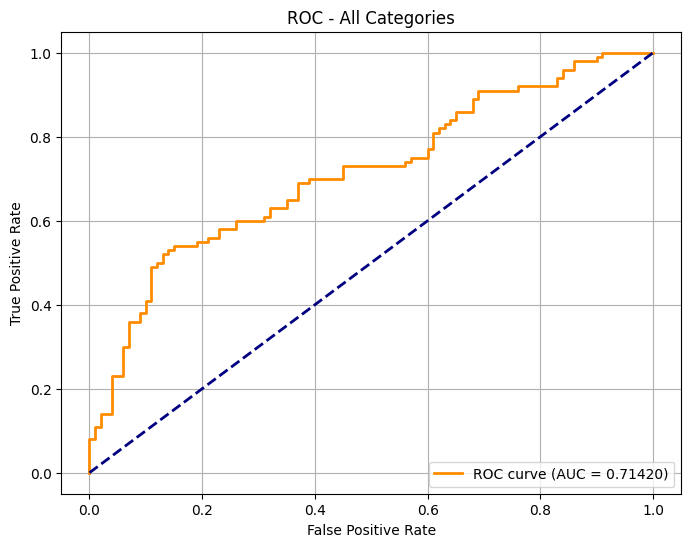

In [23]:
# Plot results
evaluator.plot_results()

In [24]:
# After running thorough_eval
augmentation_results = evaluator.augmentation_robustness_eval(
    num_samples=50,
    #augmentation_ids=[0, 1, 2]
)

Testing robustness against different augmentation types...
Generating samples without augmentation...
All samples already generated.
Testing augmentation: RandomRotation (0)...
Scoring non-watermarked samples...
Scoring watermarked samples...
Plots saved to results/SERUM_demo/evaluation with prefix augmentation_RandomRotation (0)
RandomRotation (0): 8.0000% TPR @ 0.0000% FPR (ROC AUC: 0.7004)
RandomRotation (0): 100.0000% TPR @ 92.0000% FPR (ROC AUC: 0.7004)
Testing augmentation: Compose (1)...
Scoring non-watermarked samples...
Scoring watermarked samples...
Plots saved to results/SERUM_demo/evaluation with prefix augmentation_Compose (1)
Compose (1): 16.0000% TPR @ 0.0000% FPR (ROC AUC: 0.7732)
Compose (1): 100.0000% TPR @ 92.0000% FPR (ROC AUC: 0.7732)
Testing augmentation: RandomResizedCrop (2)...
Scoring non-watermarked samples...
Scoring watermarked samples...
Plots saved to results/SERUM_demo/evaluation with prefix augmentation_RandomResizedCrop (2)
RandomResizedCrop (2): 10.000

In [25]:
_ = evaluator.watermark_detection_time(num_samples=100, batch_size=32)

Measuring watermark detection time over 100 samples...


Generating batches:   0%|          | 0/2 [00:00<?, ?it/s]The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', ', uncropped <|endoftext|>!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', 'krenz cushart <|endoftext|>!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!',

  0%|          | 0/50 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', ', uncropped <|endoftext|>!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', 'krenz cushart <|endoftext|>!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!', '!!!!!!!!!!!!!

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['studio ghibli <|endoftext|>!!!!!!!!!', '!!!!!!!!!!!!', '!!!!!!!!!!!!', '!!!!!!!!!!!!', '!!!!!!!!!!!!', '!!!!!!!!!!!!', '!!!!!!!!!!!!', '!!!!!!!!!!!!', '!!!!!!!!!!!!', '!!!!!!!!!!!!', 'kentarõ miura style , trending on art station', '!!!!!!!!!!!!', '!!!!!!!!!!!!', 'octane render , 8 k , depth of field , 3 d', '!!!!!!!!!!!!', '!!!!!!!!!!!!', '!!!!!!!!!!!!', '!!!!!!!!!!!!']


  0%|          | 0/50 [00:00<?, ?it/s]

Generating batches: 100%|██████████| 2/2 [01:33<00:00, 46.66s/it]


Generated 50 clean and watermarked images.
Scoring non-watermarked samples...
Scoring watermarked samples...

=== Watermark Detection Time Results ===
Clean samples detection time: 7.5605 seconds
Watermarked samples detection time: 7.4193 seconds
Total detection time: 14.9798 seconds
Total samples processed: 200
Average time per sample: 0.074899 seconds
Samples per second: 13.35


In [26]:
cleanup_cuda_memory(True)

CUDA Memory - Allocated: 2.66GB, Cached: 2.78GB, Free: 36.08GB, Total: 39.39GB


## FID & CLIP

In [28]:
# Load prompts and COCO images
generate.load_coco(
    config=config,
    annotation_path="./COCO/captions_val2014.json",
    images_path="./COCO/val2014",
    num_samples=100
)

Extracted 100 unique (image_id, prompt) pairs
Sample prompt (COCO_val2014_000000341921.jpg): A young boy sits and reads a book on a bench at a quiet park.
Created directory: results/SERUM_demo/gen_images/original


Copying images: 100%|██████████| 100/100 [00:12<00:00,  8.30it/s]

Successfully copied 100/100 images


In [29]:
# Load COCO images from existing prompts file
# (Alternatively, you can provide your own prompts file from COCO)
generate.load_coco_images_from_prompts(
    config=config,
    annotation_path="./COCO/captions_val2014.json",
    images_path="./COCO/val2014",
    prompts_path="./COCO/prompts.txt",
    num_samples=100
)

Removed existing directory: results/SERUM_demo/gen_images/original
[000008] Warning: Multiple entries found for prompt 'A pizza sitting on top of a wooden cutting board.'. Using the first one.
[000010] Warning: Multiple entries found for prompt 'A group of men on a field playing baseball.'. Using the first one.
[000012] Warning: Multiple entries found for prompt 'A man is riding the waves on a surfboard.'. Using the first one.
[000022] Warning: Multiple entries found for prompt 'A group of young women playing a game of soccer.'. Using the first one.
[000023] Warning: Multiple entries found for prompt 'A kitchen that is very nice and clean.'. Using the first one.
[000029] Warning: Multiple entries found for prompt 'A tennis player is getting ready to hit a ball.'. Using the first one.
[000033] Warning: Multiple entries found for prompt 'A man flying through the air while riding a snowboard.'. Using the first one.
[000064] Warning: Multiple entries found for prompt 'A young man playing t

In [30]:
# Based on the loaded prompts, generate images with and without watermark
generate.generate(
    config=config,
    diffusion_model=diffusion_model,
    watermark=watermark,
    num_samples=100,
    force_reload=True
)

Removed existing directory: results/SERUM_demo/gen_images/clean
Removed existing directory: results/SERUM_demo/gen_images/watermarked


Generating batches:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Generating batches:  25%|██▌       | 1/4 [00:56<02:48, 56.10s/it]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Generating batches: 100%|██████████| 4/4 [03:05<00:00, 46.29s/it]

Generated 100 clean and watermarked images.


('results/SERUM_demo/gen_images/clean',
 'results/SERUM_demo/gen_images/watermarked')

Visualizing 2 samples...
Displaying 2 samples


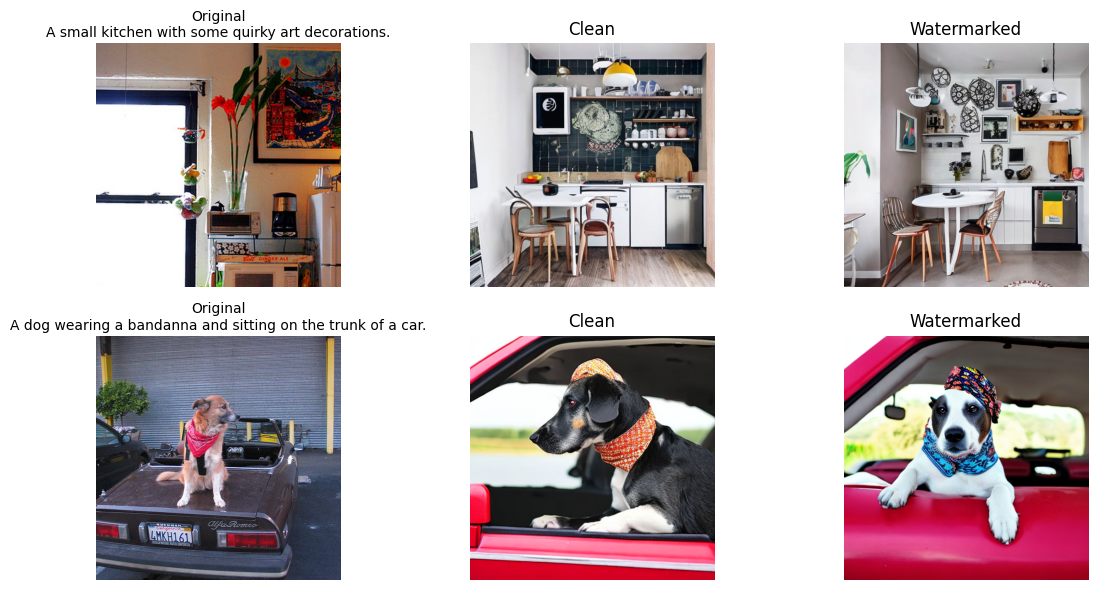

Visualization complete for 2 samples


In [31]:
scores.visualize_samples(config, num_samples=2)

In [32]:
_ = scores.calculate_fid(config)

Calculating FID scores...
Calculating FID: Clean vs Original...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /home/c01huja/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:01<00:00, 75.5MB/s]
/home/c01huja/CISPA-home/miniconda3/envs/serum_final/lib/python3.13/site-packages/torch_fidelity/datasets.py:16: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  img = torch.ByteTensor(torch.ByteStorage.from_buffer(img.tobytes())).view(height, width, 3)


FID (Clean vs Original): 182.5931
Calculating FID: Watermarked vs Original...
FID (Watermarked vs Original): 184.2415
Calculating FID: Clean vs Watermarked...
FID (Clean vs Watermarked): 127.2833

=== FID Results Summary ===
fid_clean_original: 182.5931
fid_watermarked_original: 184.2415
fid_clean_watermarked: 127.2833


Loading CLIP model...


100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 78.1MiB/s]


Preprocessing images...
Calculating CLIP scores for clean images...


100%|██████████| 2/2 [00:00<00:00,  6.57it/s]


Calculating CLIP scores for watermarked images...


100%|██████████| 2/2 [00:00<00:00, 41.92it/s]


Mean CLIP Score (Clean): 0.3108
Mean CLIP Score (Watermarked): 0.3076


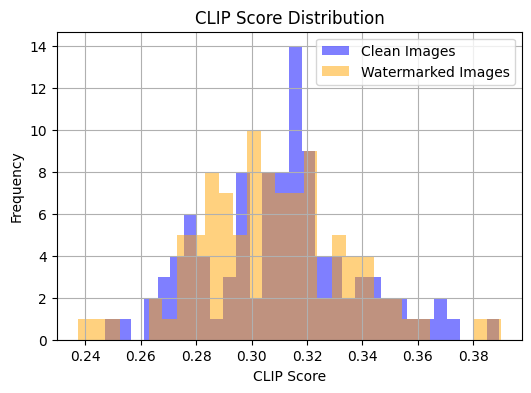

In [33]:
_ = scores.calculate_clip_score(
    config=config,
    clip_model_name="ViT-B/32",
    batch_size=64
)

In [34]:
cleanup_cuda_memory(True)

CUDA Memory - Allocated: 2.66GB, Cached: 2.78GB, Free: 36.08GB, Total: 39.39GB
